In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-image pywavelets opencv-python

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew
import pywt
from tqdm import tqdm

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/app_paper_/ApplePaper"

CLASSES = ["Defected", "NonDefected"]
IMG_SIZE = 224

In [ ]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return img, gray

In [ ]:
def extract_glcm_features(gray):
    glcm = graycomatrix(gray,
                        distances=[1],
                        angles=[0],
                        levels=256,
                        symmetric=True,
                        normed=True)

    features = []
    props = ['contrast', 'energy', 'homogeneity', 'correlation']

    for prop in props:
        features.append(graycoprops(glcm, prop)[0, 0])

    return features

In [ ]:
def extract_lbp_features(gray):
    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')

    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           range=(0, n_points + 2))

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist.tolist()

In [ ]:
def extract_color_features(img):
    features = []

    for i in range(3):  # B, G, R channels
        channel = img[:, :, i]

        features.append(np.mean(channel))
        features.append(np.var(channel))
        features.append(skew(channel.reshape(-1)))

    return features

In [ ]:
def extract_dwt_features(gray):
    coeffs2 = pywt.dwt2(gray, 'haar')
    LL, (LH, HL, HH) = coeffs2

    features = []

    for comp in [LL, LH, HL, HH]:
        features.append(np.mean(comp))
        features.append(np.var(comp))

    return features

In [ ]:
def extract_tamura_features(gray):
    gray = gray.astype(np.float32)

    features = []

    # --- Contrast ---
    mean = np.mean(gray)
    std = np.std(gray)
    kurtosis = np.mean((gray - mean)**4) / (std**4 + 1e-6)
    contrast = std / (kurtosis ** 0.25 + 1e-6)

    # --- Coarseness ---
    scales = [1, 2, 4]
    coarseness = 0
    for scale in scales:
        resized = cv2.resize(gray,
                             (gray.shape[1]//scale, gray.shape[0]//scale))
        coarseness += np.var(resized)
    coarseness /= len(scales)

    # --- Directionality ---
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1)

    orientation = np.arctan2(sobely, sobelx)
    directionality = np.var(orientation)

    features.extend([coarseness, contrast, directionality])

    return features

In [ ]:
def extract_features_by_group(img_path):
    img, gray = preprocess_image(img_path)

    glcm = extract_glcm_features(gray)
    lbp = extract_lbp_features(gray)
    tamura = extract_tamura_features(gray)
    color = extract_color_features(img)
    dwt = extract_dwt_features(gray)

    return {
        "glcm": glcm,
        "lbp": lbp,
        "tamura": tamura,
        "color": color,
        "dwt": dwt,
        "combined": glcm + lbp + tamura + color + dwt
    }

In [ ]:
feature_data = {
    "glcm": [],
    "lbp": [],
    "tamura": [],
    "color": [],
    "dwt": [],
    "combined": []
}

labels = []

for label, class_name in enumerate(CLASSES):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            features = extract_features_by_group(img_path)

            for key in feature_data:
                feature_data[key].append(features[key])

            labels.append(label)

        except:
            continue

In [ ]:
#New

In [ ]:
# Convert to numpy
X_combined = np.array(feature_data["combined"])
y = np.array(labels)

print("Feature shape:", X_combined.shape)

Feature shape: (1380, 34)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
!pip install catboost
!pip install ngboost lightgbm xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 34.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=2890c9ede8d3f80552223c0829a6800b15bd62cb729aa7fff8feab9099ed5577
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        end = time.time()

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds),
            "Inference_Time_ms": (end - start) * 1000
        })

    return pd.DataFrame(results)

In [ ]:
results_combined = evaluate_models(models, X_train, X_test, y_train, y_test)
print("=== Combined Features Results ===")
print(results_combined.sort_values(by="Accuracy", ascending=False))


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:09:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 552, number of negative: 552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001716 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8670
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Combined Features Results ===
              Model  Accuracy  Precision    Recall        F1  \
3        ExtraTrees  0.952899   0.977099  0.927536  0.951673   
8          CatBoost  0.952899   0.969925  0.934783  0.952030   
0      RandomForest  0.945652   0.969466  0.920290  0.944238   
5  GradientBoosting  0.942029   0.962121  0.920290  0.940741   
7          LightGBM  0.942029   0.955224  0.927536  0.941176   
6           XGBoost  0.934783   0.954545  0.913043  0.933333   
4          AdaBoost  0.913043   0.931818  0.891304  0.911111   
2               KNN  0.862319   0.884615  0.833333  0.858209   
1               SVM  0.815217   0.800000  0.840580  0.819788   

   Inference_Time_ms  
3         408.664942  
8       21393.431902  
0        1372.058153  
5        6765.338898  
7         590.337515  
6        1512.250662  
4         925.661802  
2          83.673716  
1         536.740780  


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf_rfe = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rfe = RFE(
    estimator=rf_rfe,
    n_features_to_select=15
)

# Select features using training data only
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Apply the same selected features to test data
X_test_rfe = rfe.transform(X_test)

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_rfe.shape[1])

Original features: 34
Selected features: 15


In [63]:
rf_rfe.fit(X_train_rfe, y_train)

RandomForestClassifier(random_state=42)

In [60]:
import pandas as pd
from IPython.display import display, HTML

selected_features = [
    'GLCM_Energy',
    'GLCM_Homogeneity',
    'LBP_1',
    'LBP_2',
    'LBP_6',
    'LBP_8',
    'LBP_9',
    'Color_Var_B',
    'Color_Skew_B',
    'Color_Mean_G',
    'Color_Var_R',
    'DWT_LL_Mean',
    'DWT_LH_Mean',
    'DWT_LH_Var',
    'DWT_HL_Mean'
]

importances = rf.feature_importances_

feat_table = pd.DataFrame({
    "Feature Name": selected_features,
    "Importance": importances
})

feat_table = feat_table.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Clean plain-white professional table
html = feat_table.to_html(
    index=False,
    float_format=lambda x: f"{x:.4f}"
)

html = html.replace(
    '<table border="1" class="dataframe">',
    '''<table style="
        background-color: white;
        color: black;
        border-collapse: collapse;
        width: 70%;
        font-family: Arial;
        font-size: 14px;
        border: 1px solid black;
    ">'''
)

html = html.replace(
    '<th>',
    '''<th style="
        background-color: white;
        color: black;
        padding: 10px;
        border: 1px solid black;
        text-align: center;
        font-weight: bold;
    ">'''
)

html = html.replace(
    '<td>',
    '''<td style="
        background-color: white;
        color: black;
        padding: 9px;
        border: 1px solid black;
        text-align: center;
    ">'''
)

display(HTML(html))

Feature Name,Importance
Color_Var_B,0.1287
LBP_2,0.1088
DWT_LH_Mean,0.0793
Color_Skew_B,0.0786
Color_Var_R,0.0780
LBP_9,0.0692
DWT_LL_Mean,0.0651
LBP_8,0.0575
GLCM_Homogeneity,0.0543
DWT_HL_Mean,0.0513


In [65]:
def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():
        start = time.time()

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        end = time.time()

        results[name] = {
            "accuracy": accuracy_score(y_test, preds),
            "time": end - start
        }

    return results

In [66]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfe_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_combined, y), start=1):

    X_train_fold = X_combined[train_idx]
    X_val_fold = X_combined[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]

    # RFE is fitted only on the training portion
    rfe_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rfe = RFE(
        estimator=rfe_model,
        n_features_to_select=15
    )

    X_train_fold_rfe = rfe.fit_transform(
        X_train_fold,
        y_train_fold
    )

    X_val_fold_rfe = rfe.transform(
        X_val_fold
    )

    # Train Random Forest using the selected 15 features
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(
        X_train_fold_rfe,
        y_train_fold
    )

    # Validation prediction
    y_val_pred = rf_model.predict(
        X_val_fold_rfe
    )

    accuracy = accuracy_score(
        y_val_fold,
        y_val_pred
    )

    rfe_cv_scores.append(accuracy)

    print(f"Fold {fold}: {accuracy * 100:.2f}%")

print("\nRFE + Random Forest 5-Fold CV")
print(f"Mean Accuracy: {np.mean(rfe_cv_scores) * 100:.2f}%")
print(f"Standard Deviation: {np.std(rfe_cv_scores) * 100:.2f}%")

Fold 1: 93.48%
Fold 2: 93.84%
Fold 3: 92.75%
Fold 4: 91.67%
Fold 5: 94.20%

RFE + Random Forest 5-Fold CV
Mean Accuracy: 93.19%
Standard Deviation: 0.90%


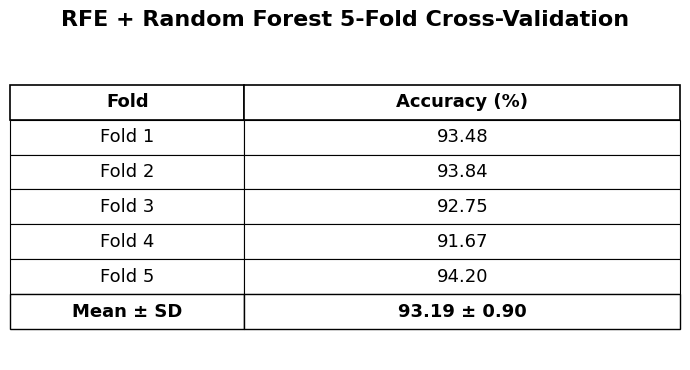

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# RFE + Random Forest 5-Fold Cross-Validation Results
cv_results_table = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 6)],
    "Accuracy (%)": [f"{score * 100:.2f}" for score in rfe_cv_scores]
})

# Add Mean ± SD
cv_results_table.loc[len(cv_results_table)] = [
    "Mean ± SD",
    f"{np.mean(rfe_cv_scores) * 100:.2f} ± {np.std(rfe_cv_scores) * 100:.2f}"
]

# Create clean white table image
fig, ax = plt.subplots(figsize=(7, 3.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# Create table
table = ax.table(
    cellText=cv_results_table.values,
    colLabels=cv_results_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.35, 0.65]
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.0)

# Remove unwanted shading and apply clean borders
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("white")
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold", color="black")
        cell.set_linewidth(1.2)

    if row == len(cv_results_table):
        cell.set_text_props(weight="bold", color="black")
        cell.set_linewidth(1.0)

# Title
ax.set_title(
    "RFE + Random Forest 5-Fold Cross-Validation",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="black"
)

plt.tight_layout()

# Save as high-resolution PNG
plt.savefig(
    "RFE_Random_Forest_5Fold_CV.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [68]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "apple_random_forest_model.joblib")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


,Features,Number of Features,Mean ± SD (%)
0,GLCM,4,82.17 ± 2.69
1,GLCM + LBP,14,89.13 ± 2.56
2,GLCM + LBP + Color,23,92.83 ± 0.96
3,GLCM + LBP + Color + Tamura,26,92.90 ± 1.23
4,GLCM + LBP + Color + Tamura + DWT,34,93.48 ± 1.32


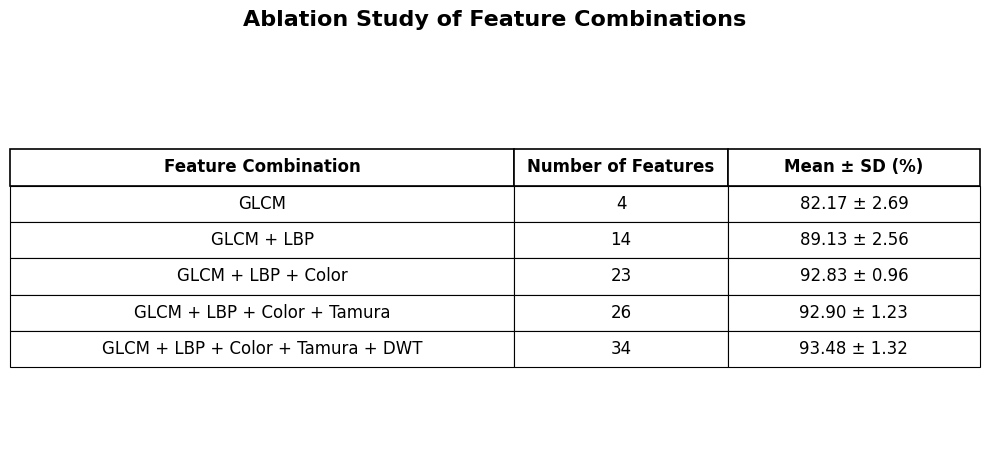

In [71]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Feature groups
feature_groups = {
    "GLCM": np.array(feature_data["glcm"]),
    "LBP": np.array(feature_data["lbp"]),
    "Color": np.array(feature_data["color"]),
    "Tamura": np.array(feature_data["tamura"]),
    "DWT": np.array(feature_data["dwt"])
}

# Progressive feature combinations
ablation_combinations = [
    ["GLCM"],
    ["GLCM", "LBP"],
    ["GLCM", "LBP", "Color"],
    ["GLCM", "LBP", "Color", "Tamura"],
    ["GLCM", "LBP", "Color", "Tamura", "DWT"]
]

# 5-Fold Cross-Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ablation_results = []

for combination in ablation_combinations:

    # Create feature combination
    X_ablation = np.hstack(
        [feature_groups[group] for group in combination]
    )

    fold_scores = []

    for train_idx, val_idx in skf.split(X_ablation, y):

        X_train_fold = X_ablation[train_idx]
        X_val_fold = X_ablation[val_idx]

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # Same Random Forest classifier for every combination
        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )

        rf.fit(X_train_fold, y_train_fold)

        y_pred = rf.predict(X_val_fold)

        fold_scores.append(
            accuracy_score(y_val_fold, y_pred)
        )

    mean_accuracy = np.mean(fold_scores)
    std_accuracy = np.std(fold_scores)

    ablation_results.append({
        "Features": " + ".join(combination),
        "Number of Features": X_ablation.shape[1],
        "Mean Accuracy (%)": mean_accuracy * 100,
        "SD (%)": std_accuracy * 100
    })

# Create results DataFrame
ablation_df = pd.DataFrame(ablation_results)

# Format Mean ± SD
ablation_df["Mean ± SD (%)"] = (
    ablation_df["Mean Accuracy (%)"].map(lambda x: f"{x:.2f}")
    + " ± "
    + ablation_df["SD (%)"].map(lambda x: f"{x:.2f}")
)

# Display clean table
display(
    ablation_df[
        ["Features", "Number of Features", "Mean ± SD (%)"]
    ]
)

# --------------------------------------------------
# Create clean publication-quality table image
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

table_data = ablation_df[
    ["Features", "Number of Features", "Mean ± SD (%)"]
].values

table = ax.table(
    cellText=table_data,
    colLabels=[
        "Feature Combination",
        "Number of Features",
        "Mean ± SD (%)"
    ],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.52, 0.22, 0.26]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.0)

# Completely white cells with clean borders
for (row, col), cell in table.get_celld().items():

    cell.set_facecolor("white")
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(
            weight="bold",
            color="black"
        )
        cell.set_linewidth(1.2)

# Title
ax.set_title(
    "Ablation Study of Feature Combinations",
    fontsize=16,
    fontweight="bold",
    color="black",
    pad=22
)

plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "Ablation_Study_Feature_Combinations.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
**** ABLATION STUDY ****

In [72]:
final_results = results_combined.merge(
    results_rfe,
    on="Model",
    suffixes=("_Combined", "_RFE")
)

from IPython.display import display, HTML

combined_cols = [
    col for col in final_results.columns
    if col == "Model" or col.endswith("_Combined")
]

rfe_cols = [
    col for col in final_results.columns
    if col == "Model" or col.endswith("_RFE")
]

def make_table(df, title):
    headers = "".join(
        f'<th style="border:1px solid black; padding:10px; '
        f'text-align:center; background:white;">{col}</th>'
        for col in df.columns
    )

    rows = "".join(
        "<tr>" +
        "".join(
            f'<td style="border:1px solid black; padding:9px; '
            f'text-align:center; background:white;">{value}</td>'
            for value in row
        ) +
        "</tr>"
        for row in df.itertuples(index=False, name=None)
    )

    return f"""
    <h3 style="text-align:center; color:black; margin:15px 0 10px;">
        {title}
    </h3>

    <table style="
        width:100%;
        border-collapse:collapse;
        background:white;
        color:black;
        font-size:13px;
    ">
        <thead>
            <tr>{headers}</tr>
        </thead>
        <tbody>{rows}</tbody>
    </table>
    """

display(HTML(f"""
<div style="
    background:white;
    padding:15px;
    width:850px;
    color:black;
    font-family:Arial;
">
    {make_table(final_results[combined_cols], "Combined Features")}

    <br>

    {make_table(final_results[rfe_cols], "RFE Features")}
</div>
"""))

Model,Accuracy_Combined,Precision_Combined,Recall_Combined,F1_Combined,Inference_Time_ms_Combined
RandomForest,0.9456521739130435,0.9694656488549618,0.9202898550724637,0.9442379182156134,1372.0581531524658
SVM,0.8152173913043478,0.8,0.8405797101449275,0.8197879858657244,536.740779876709
KNN,0.8623188405797102,0.8846153846153846,0.8333333333333334,0.8582089552238806,83.67371559143066
ExtraTrees,0.9528985507246377,0.9770992366412213,0.927536231884058,0.9516728624535316,408.6649417877197
AdaBoost,0.9130434782608695,0.9318181818181818,0.8913043478260869,0.9111111111111111,925.6618022918701
GradientBoosting,0.9420289855072463,0.9621212121212122,0.9202898550724637,0.9407407407407408,6765.338897705078
XGBoost,0.9347826086956522,0.9545454545454546,0.9130434782608695,0.9333333333333333,1512.2506618499756
LightGBM,0.9420289855072463,0.9552238805970149,0.927536231884058,0.9411764705882353,590.3375148773193
CatBoost,0.9528985507246377,0.9699248120300752,0.9347826086956522,0.9520295202952029,21393.431901931763
Model,Accuracy_RFE,Precision_RFE,Recall_RFE,F1_RFE,Inference_Time_ms_RFE


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import seaborn as sns

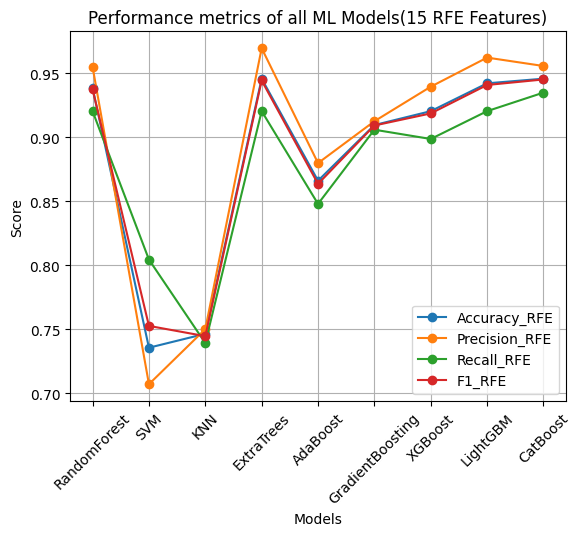

In [73]:
import matplotlib.pyplot as plt

metrics = ["Accuracy_RFE", "Precision_RFE", "Recall_RFE", "F1_RFE"]

for metric in metrics:
    plt.plot(final_results["Model"], final_results[metric], marker='o', label=metric)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Performance metrics of all ML Models(15 RFE Features)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:06:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 552, number of negative: 552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


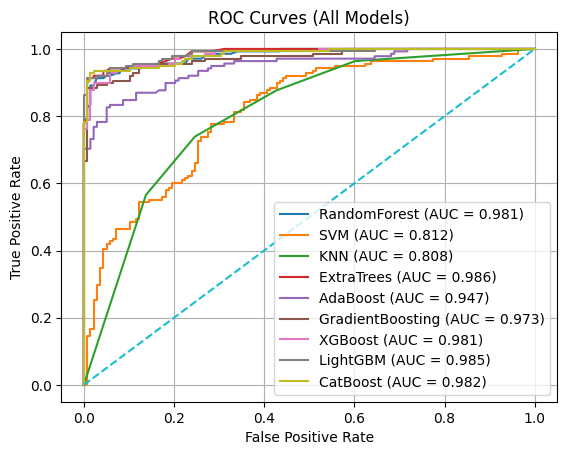

In [74]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    model.fit(X_train_rfe, y_train)
    probs = model.predict_proba(X_test_rfe)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (All Models)")
plt.legend()
plt.grid()
plt.show()

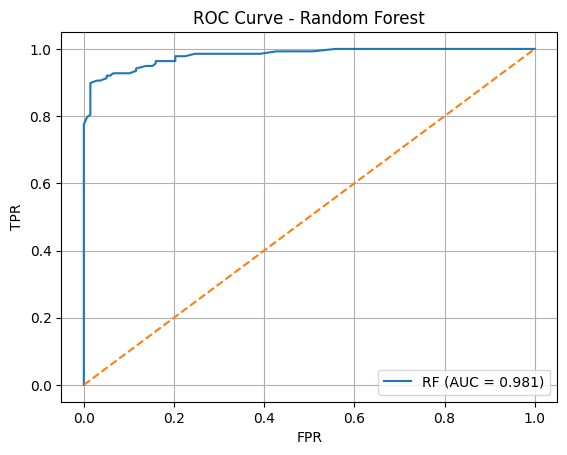

In [75]:
rf = RandomForestClassifier()
rf.fit(X_train_rfe, y_train)

probs = rf.predict_proba(X_test_rfe)[:, 1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

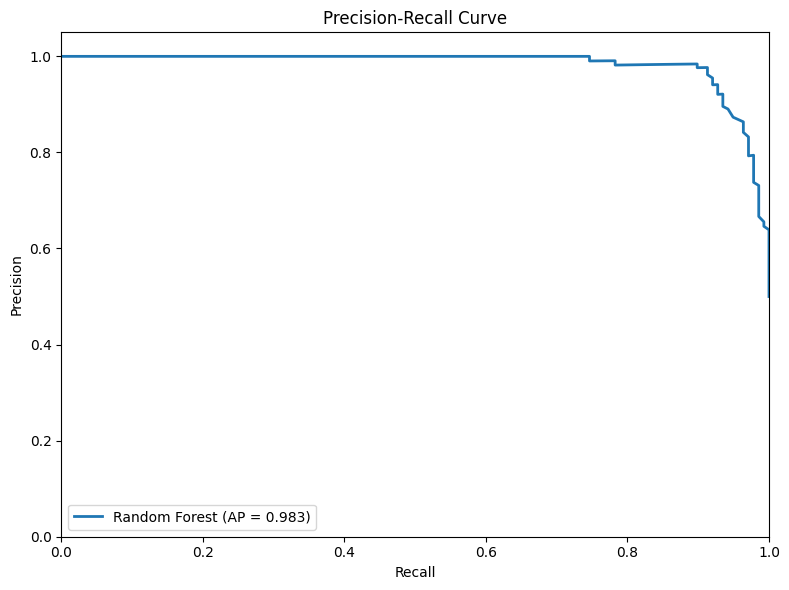

Average Precision (AP): 0.9826


In [76]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

rf_prob = rf_rfe.predict_proba(X_test_rfe)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

average_precision = average_precision_score(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Random Forest (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(False)
plt.legend()

plt.gca().set_facecolor("white")
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {average_precision:.4f}")

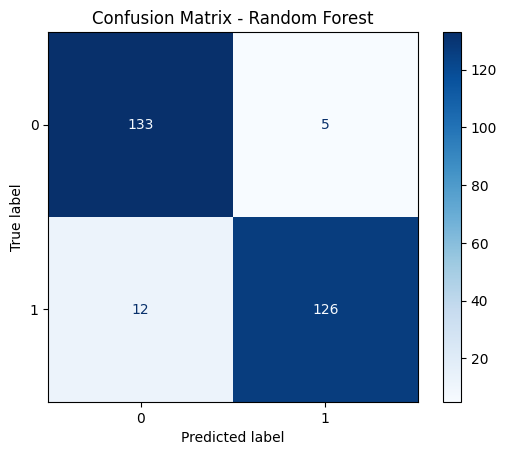

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf = RandomForestClassifier()
rf.fit(X_train_rfe, y_train)

preds = rf.predict(X_test_rfe)

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

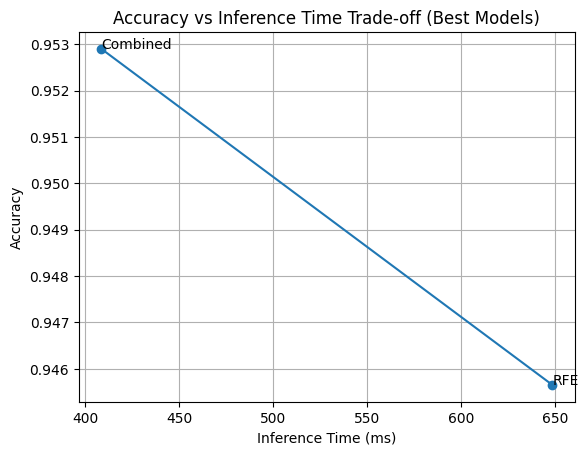

In [78]:
import matplotlib.pyplot as plt

# Extract best models
best_combined = results_combined.loc[results_combined["Accuracy"].idxmax()]
best_rfe = results_rfe.loc[results_rfe["Accuracy"].idxmax()]

stages = ["Combined", "RFE"]
accuracy = [best_combined["Accuracy"], best_rfe["Accuracy"]]
time = [best_combined["Inference_Time_ms"], best_rfe["Inference_Time_ms"]]

# Plot
plt.plot(time, accuracy, marker='o')

# Annotate points
for i, stage in enumerate(stages):
    plt.text(time[i], accuracy[i], stage)

plt.xlabel("Inference Time (ms)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Inference Time Trade-off (Best Models)")
plt.grid()
plt.show()

In [79]:
feature_names = []

# GLCM
feature_names += ["GLCM_Contrast", "GLCM_Energy", "GLCM_Homogeneity", "GLCM_Correlation"]

# LBP (10 bins)
feature_names += [f"LBP_{i}" for i in range(10)]

# Tamura
feature_names += ["Tamura_Coarseness", "Tamura_Contrast", "Tamura_Directionality"]

# Color (9 features)
color_names = ["Mean", "Var", "Skew"]
channels = ["B", "G", "R"]

for c in channels:
    for stat in color_names:
        feature_names.append(f"Color_{stat}_{c}")

# DWT (8 features)
dwt_parts = ["LL", "LH", "HL", "HH"]
for part in dwt_parts:
    feature_names.append(f"DWT_{part}_Mean")
    feature_names.append(f"DWT_{part}_Var")

print(len(feature_names))  # Should be 34

34


In [80]:
selected_features = np.array(feature_names)[rfe.support_]

print(selected_features)

['GLCM_Energy' 'GLCM_Homogeneity' 'LBP_1' 'LBP_2' 'LBP_6' 'LBP_8' 'LBP_9'
 'Color_Var_B' 'Color_Skew_B' 'Color_Mean_G' 'Color_Var_R' 'DWT_LL_Mean'
 'DWT_LH_Mean' 'DWT_LH_Var' 'DWT_HL_Mean']


In [81]:
import pandas as pd

importances = rf.feature_importances_

feat_table = pd.DataFrame({
    "Feature Name": selected_features,
    "Importance": importances
})

feat_table = feat_table.sort_values(by="Importance", ascending=False)

print(feat_table)

        Feature Name  Importance
7        Color_Var_B    0.130534
3              LBP_2    0.099818
8       Color_Skew_B    0.082774
10       Color_Var_R    0.081460
12       DWT_LH_Mean    0.074539
1   GLCM_Homogeneity    0.064415
6              LBP_9    0.062314
11       DWT_LL_Mean    0.060602
5              LBP_8    0.058601
14       DWT_HL_Mean    0.053071
2              LBP_1    0.047770
0        GLCM_Energy    0.047653
13        DWT_LH_Var    0.046514
9       Color_Mean_G    0.045488
4              LBP_6    0.044446


In [82]:
print("Selected features:", len(selected_features))
print("RF importances:", len(rf.feature_importances_))

Selected features: 15
RF importances: 15


In [83]:
print(type(rf))
print(rf.n_features_in_)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
15


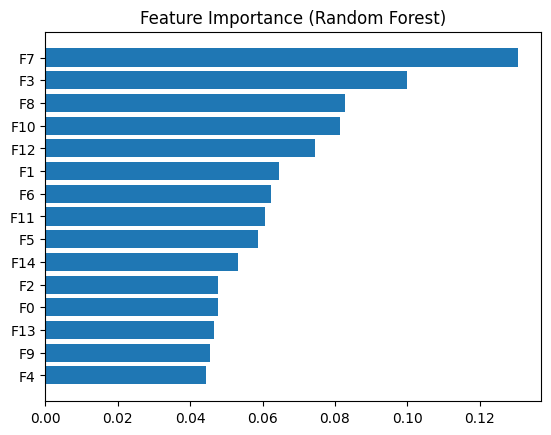

In [84]:
import pandas as pd

feature_names = [f"F{i}" for i in range(X_train_rfe.shape[1])]

importances = rf.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [85]:
import shap
import numpy as np

# Create SHAP explainer for the RFE Random Forest
explainer = shap.TreeExplainer(rf_rfe)

# Calculate SHAP values for the RFE test features
shap_values = explainer.shap_values(X_test_rfe)

# Select SHAP values for the positive class
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print("SHAP values calculated successfully")
print("Test samples:", X_test_rfe.shape[0])
print("Selected features:", X_test_rfe.shape[1])

SHAP values calculated successfully
Test samples: 276
Selected features: 15


In [86]:
print("X_test_rfe shape:", X_test_rfe.shape)
print("SHAP values shape:", np.array(shap_values).shape)
print("SHAP values plot shape:", np.array(shap_values_plot).shape)

X_test_rfe shape: (276, 15)
SHAP values shape: (276, 15, 2)
SHAP values plot shape: (276, 15, 2)


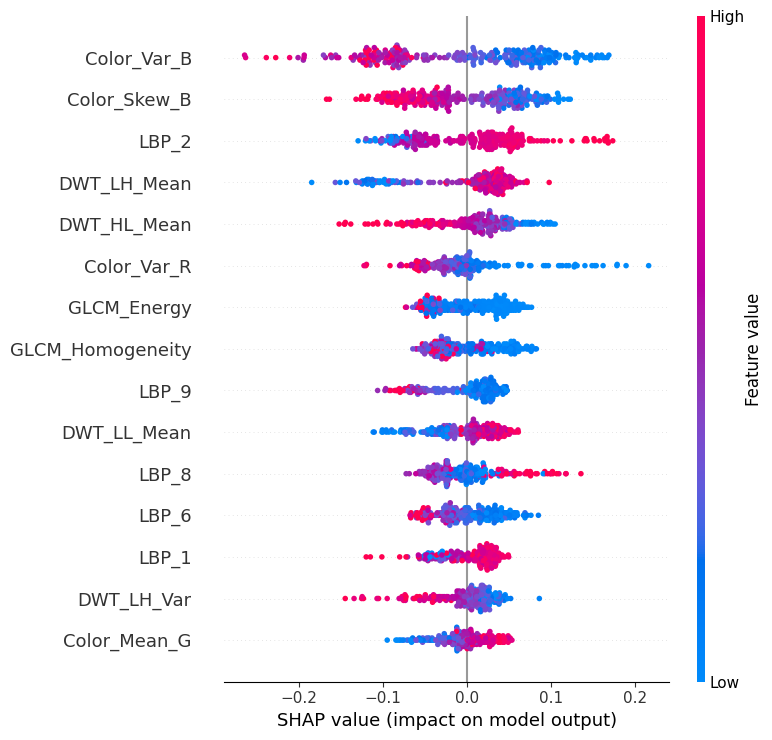

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Select SHAP values for class 1
shap_values_plot = shap_values[:, :, 1]

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_plot,
    X_test_rfe,
    feature_names=selected_features,
    max_display=15,
    show=False
)

fig = plt.gcf()
fig.set_facecolor("white")

for ax in fig.axes:
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()

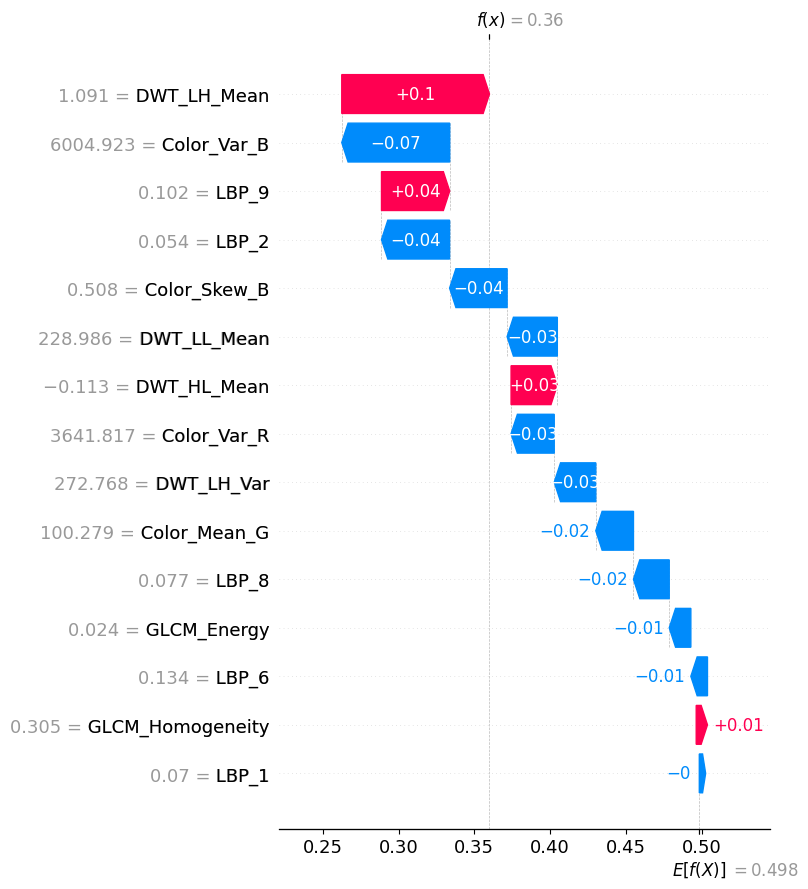

In [88]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Select one test sample
sample_index = 0
sample = X_test_rfe[sample_index]

# SHAP values for the selected sample
sample_shap = shap_values[sample_index, :, 1]

# Base value for class 1
base_value = explainer.expected_value[1]

# Create a clean local SHAP explanation
explanation = shap.Explanation(
    values=sample_shap,
    base_values=base_value,
    data=sample,
    feature_names=selected_features
)

# Clean waterfall plot
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.gcf().set_facecolor("white")
plt.tight_layout()
plt.show()

Original feature shape: (1, 34)
RFE-selected feature shape: (1, 15)
----------------------------------
Apple Quality Prediction
----------------------------------
Predicted Class : Defected
Confidence      : 65.00%
----------------------------------


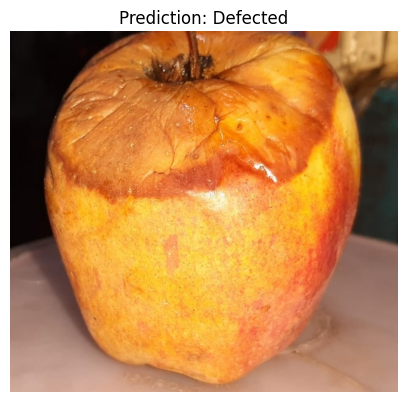

In [91]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load saved Random Forest model
# --------------------------------------------------
rf_model = joblib.load("apple_random_forest_model.joblib")

# --------------------------------------------------
# Give your image path here
# --------------------------------------------------
image_path = "/content/drive/MyDrive/apple_pap/dataset/Defected/102.jpg"

# --------------------------------------------------
# Extract features from the image
# --------------------------------------------------
features = extract_features_by_group(image_path)

# All 34 combined features
X_single = np.array(features["combined"]).reshape(1, -1)

print("Original feature shape:", X_single.shape)

# --------------------------------------------------
# Apply the SAME RFE selection used during training
# --------------------------------------------------
X_single_rfe = rfe.transform(X_single)

print("RFE-selected feature shape:", X_single_rfe.shape)

# --------------------------------------------------
# Prediction using Random Forest
# --------------------------------------------------
prediction = rf_model.predict(X_single_rfe)[0]

# Probability
probability = rf_model.predict_proba(X_single_rfe)[0]

# Class names
class_names = ["Defected", "NonDefected"]

predicted_class = class_names[prediction]
confidence = probability[prediction] * 100

# --------------------------------------------------
# Display result
# --------------------------------------------------
print("----------------------------------")
print("Apple Quality Prediction")
print("----------------------------------")
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")
print("----------------------------------")

# --------------------------------------------------
# Display image
# --------------------------------------------------
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()

Original feature shape: (1, 34)
RFE-selected feature shape: (1, 15)
----------------------------------
Apple Quality Prediction
----------------------------------
Predicted Class : NonDefected
Confidence      : 66.00%
----------------------------------


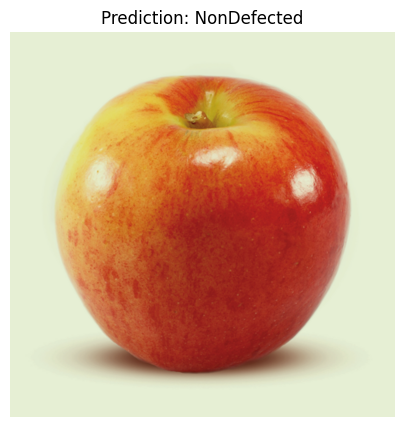

In [92]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load saved Random Forest model
# --------------------------------------------------
rf_model = joblib.load("apple_random_forest_model.joblib")

# --------------------------------------------------
# Give your image path here
# --------------------------------------------------
image_path = "/content/drive/MyDrive/apple_pap/dataset/NonDefected/123.png"

# --------------------------------------------------
# Extract features from the image
# --------------------------------------------------
features = extract_features_by_group(image_path)

# All 34 combined features
X_single = np.array(features["combined"]).reshape(1, -1)

print("Original feature shape:", X_single.shape)

# --------------------------------------------------
# Apply the SAME RFE selection used during training
# --------------------------------------------------
X_single_rfe = rfe.transform(X_single)

print("RFE-selected feature shape:", X_single_rfe.shape)

# --------------------------------------------------
# Prediction using Random Forest
# --------------------------------------------------
prediction = rf_model.predict(X_single_rfe)[0]

# Probability
probability = rf_model.predict_proba(X_single_rfe)[0]

# Class names
class_names = ["Defected", "NonDefected"]

predicted_class = class_names[prediction]
confidence = probability[prediction] * 100

# --------------------------------------------------
# Display result
# --------------------------------------------------
print("----------------------------------")
print("Apple Quality Prediction")
print("----------------------------------")
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")
print("----------------------------------")

# --------------------------------------------------
# Display image
# --------------------------------------------------
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()